In [61]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
from pathlib import Path
from scipy.interpolate import interp1d

In [62]:
mc_dose_profile_path = Path('graph_entryx_DOSE.csv')
mc_fluence_profile_path = Path('graph_entryx_FLUENCE.csv')
mc_kinetic_energy_path = Path('graph_entryx_AVG-ENERGY.csv')
mc_dose_profile_path.exists(), mc_fluence_profile_path.exists(), mc_kinetic_energy_path.exists()

(True, True, True)

In [63]:
def calculate_dose_metrics(df_data, data_name="Data", ref_x_coord=None, interp_func=None):
    """
    Calculate dose metrics for a dataset.
    
    Parameters:
    - df_data: DataFrame with 'depth' (in mm) and 'dose' (normalized) columns, or 'x' and 'y'
    - data_name: Name of the dataset for display
    - ref_x_coord: Reference x-coordinate for interpolating the first point (used for MC data)
    - interp_func: Interpolation function to use for first point value (used for MC data)
    
    Returns:
    - Dictionary with calculated metrics
    """
    if df_data is None or df_data.empty:
        print(f"{data_name} not loaded")
        return None
    
    # Determine column names
    x_col = 'x' if 'x' in df_data.columns else 'depth'
    y_col = 'y' if 'y' in df_data.columns else 'dose'
    
    metrics = {}
    
    # 1. Find distance where dose is 0.9 (scanning right to left) - called "Range"
    dose_09 = None
    for i in range(len(df_data) - 1, 0, -1):
        y_curr = df_data[y_col].iloc[i]
        y_prev = df_data[y_col].iloc[i-1]
        # Check for transition where we cross 0.9
        if y_curr <= 0.9 and y_prev > 0.9:
            x_curr, x_prev = df_data[x_col].iloc[i], df_data[x_col].iloc[i-1]
            # Linear interpolation to find x where y = 0.9
            dose_09 = x_prev + (0.9 - y_prev) * (x_curr - x_prev) / (y_curr - y_prev)
            break
    
    # 1b. Find distance where dose drops to 0.1 (scanning right to left)
    dose_01 = None
    for i in range(len(df_data) - 1, 0, -1):
        y_curr = df_data[y_col].iloc[i]
        y_prev = df_data[y_col].iloc[i-1]
        # Check for transition where we cross 0.1
        if y_curr <= 0.1 and y_prev > 0.1:
            x_curr, x_prev = df_data[x_col].iloc[i], df_data[x_col].iloc[i-1]
            # Linear interpolation to find x where y = 0.1
            dose_01 = x_prev + (0.1 - y_prev) * (x_curr - x_prev) / (y_curr - y_prev)
            break
    
    # Calculate drop distance from 0.9 to 0.1
    dose_drop_09_to_01 = None
    if dose_09 is not None and dose_01 is not None:
        dose_drop_09_to_01 = dose_01 - dose_09
    
    # 2. Calculate FWHM (Full Width at Half Maximum)
    # Find points where dose = 0.5
    # Scanning left to right (first crossing)
    fwhm_left = None
    for i in range(len(df_data) - 1):
        y1, y2 = df_data[y_col].iloc[i], df_data[y_col].iloc[i+1]
        if y1 < 0.5 and y2 >= 0.5:
            x1, x2 = df_data[x_col].iloc[i], df_data[x_col].iloc[i+1]
            fwhm_left = x1 + (0.5 - y1) * (x2 - x1) / (y2 - y1)
            break
    
    # Scanning right to left (second crossing)
    fwhm_right = None
    for i in range(len(df_data) - 1, 0, -1):
        y_curr = df_data[y_col].iloc[i]
        y_prev = df_data[y_col].iloc[i-1]
        if y_curr < 0.5 and y_prev >= 0.5:
            x_curr, x_prev = df_data[x_col].iloc[i], df_data[x_col].iloc[i-1]
            fwhm_right = x_prev + (0.5 - y_prev) * (x_curr - x_prev) / (y_curr - y_prev)
            break
    
    if fwhm_left is not None and fwhm_right is not None:
        fwhm = fwhm_right - fwhm_left
    else:
        fwhm = None
    
    # 3. Calculate inverse of the first point value (Max to Plateau Ratio)
    # Use interpolated value at ref_x_coord if provided, otherwise use first point
    if ref_x_coord is not None and interp_func is not None:
        try:
            first_point_value = float(interp_func(ref_x_coord))
            first_point_inverse = 1.0 / first_point_value
        except:
            first_point_inverse = 1.0 / df_data[y_col].iloc[0]
    else:
        first_point_inverse = 1.0 / df_data[y_col].iloc[0]
    
    metrics['dose_09'] = dose_09
    metrics['dose_01'] = dose_01
    metrics['dose_drop_09_to_01'] = dose_drop_09_to_01
    metrics['fwhm_left'] = fwhm_left
    metrics['fwhm_right'] = fwhm_right
    metrics['fwhm'] = fwhm
    metrics['first_point_inverse'] = first_point_inverse
    
    # Print results (convert from mm to cm for distances)
    print(f"=== {data_name} Metrics ===")
    print(f"Range (distance at dose 0.9): {dose_09 / 10:.4f} cm" if dose_09 is not None else f"Range (distance at dose 0.9): Not found")
    print(f"Distance at dose 0.1: {dose_01 / 10:.4f} cm" if dose_01 is not None else "Distance at dose 0.1: Not found")
    print(f"Drop from 0.9 to 0.1: {dose_drop_09_to_01 / 10:.4f} cm" if dose_drop_09_to_01 is not None else "Drop from 0.9 to 0.1: Not calculated")
    print(f"FWHM: {fwhm / 10:.4f} cm" if fwhm is not None else "FWHM: Not calculated")
    print(f"Left edge of FWHM (0.5): {fwhm_left / 10:.4f} cm" if fwhm_left is not None else "Left edge: Not found")
    print(f"Right edge of FWHM (0.5): {fwhm_right / 10:.4f} cm" if fwhm_right is not None else "Right edge: Not found")
    print(f"Inverse of first point value: {first_point_inverse:.4f}")
    print()
    
    return metrics

In [64]:
# Load all three CSV files
df_dose = pd.read_csv(mc_dose_profile_path, comment='#', skiprows=0)
df_fluence = pd.read_csv(mc_fluence_profile_path, comment='#', skiprows=0)
df_kinetic = pd.read_csv(mc_kinetic_energy_path, comment='#', skiprows=0)

# Strip whitespace from column names
df_dose.columns = df_dose.columns.str.strip()
df_fluence.columns = df_fluence.columns.str.strip()
df_kinetic.columns = df_kinetic.columns.str.strip()

print("Columns in dose file:", df_dose.columns.tolist())
print("Columns in fluence file:", df_fluence.columns.tolist())
print("Columns in kinetic energy file:", df_kinetic.columns.tolist())

# Extract depth column (first column) from each file
depth_col_dose = df_dose.iloc[:, 0]
depth_col_fluence = df_fluence.iloc[:, 0]
depth_col_kinetic = df_kinetic.iloc[:, 0]

# Verify that depth columns are the same
print("\n--- Verifying depth columns are identical ---")
print(f"Dose vs Fluence: {depth_col_dose.equals(depth_col_fluence)}")
print(f"Dose vs Kinetic: {depth_col_dose.equals(depth_col_kinetic)}")
print(f"Fluence vs Kinetic: {depth_col_fluence.equals(depth_col_kinetic)}")

if not (depth_col_dose.equals(depth_col_fluence) and depth_col_dose.equals(depth_col_kinetic)):
    print("WARNING: Depth columns are not identical!")
    print(f"Max difference (Dose vs Fluence): {(depth_col_dose - depth_col_fluence).abs().max()}")
    print(f"Max difference (Dose vs Kinetic): {(depth_col_dose - depth_col_kinetic).abs().max()}")
else:
    print("✓ All depth columns are identical\n")

# Get the data columns (everything except the first column)
dose_col = df_dose.iloc[:, 1]
fluence_col = df_fluence.iloc[:, 1]
kinetic_col = df_kinetic.iloc[:, 1]

# Create the merged dataframe with normalized dose and non-normalized fluence and kinetic energy
df_merged = pd.DataFrame({
    'depth': depth_col_dose * 10,  # Convert from cm to mm
    'dose': dose_col / dose_col.max(),  # Normalize dose to max value of 1
    'fluence': fluence_col,  # Not normalized
    'kinetic_energy': kinetic_col  # Not normalized
})

print(f"Merged dataframe shape: {df_merged.shape}")
print(f"Columns: {df_merged.columns.tolist()}")
print("\nFirst few rows:")
print(df_merged.head())
print("\nData summary:")
print(df_merged.describe())

Columns in dose file: ['Position (X) [cm]', 'DOSE [MeV/g/prim]']
Columns in fluence file: ['Position (X) [cm]', 'FLUENCE [/cm^2/prim]']
Columns in kinetic energy file: ['Position (X) [cm]', 'AVG-ENERGY [MeV]']

--- Verifying depth columns are identical ---
Dose vs Fluence: True
Dose vs Kinetic: True
Fluence vs Kinetic: True
✓ All depth columns are identical

Merged dataframe shape: (500, 4)
Columns: ['depth', 'dose', 'fluence', 'kinetic_energy']

First few rows:
   depth          dose   fluence  kinetic_energy
0 -24.95  5.856738e-07  0.000295        2.287464
1 -24.85  1.669564e-04  0.000279        0.867795
2 -24.75  2.454138e-04  0.000297        0.733490
3 -24.65  1.616788e-04  0.000346        0.784781
4 -24.55  7.304439e-05  0.000356        0.577924

Data summary:
            depth        dose     fluence  kinetic_energy
count  500.000000  500.000000  500.000000      500.000000
mean     0.000000    0.264505    0.048013       28.347715
std     14.448183    0.234267    0.037333       20

In [65]:
def plot_mc_data(df, title, linewidth=1, markersize=1, marker1='.', marker2='.', marker3='.'):
    """
    Plot MC data with dose, fluence, and kinetic energy on separate y-axes.
    
    Parameters:
    - df: DataFrame with columns ['depth', 'dose', 'fluence', 'kinetic_energy']
    - title: Plot title
    - linewidth: Width of the lines
    - markersize: Size of the markers
    - marker1, marker2, marker3: Marker styles for dose, fluence, and kinetic energy
    """
    if df is None or df.empty:
        print("Data not loaded")
        return
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Plot on primary y-axis (dose)
    color1 = 'tab:blue'
    ax.set_xlabel('Depth (mm)', fontsize=12)
    ax.set_ylabel('Normalized Dose', color=color1, fontsize=12)
    line1 = ax.plot(df['depth'], df['dose'], marker=marker1, linestyle='-', 
                    linewidth=linewidth, markersize=markersize, color=color1, label='Dose (normalized)')
    ax.tick_params(axis='y', labelcolor=color1)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    
    # Create second y-axis for fluence
    ax2 = ax.twinx()
    color2 = 'tab:orange'
    ax2.set_ylabel('Fluence', color=color2, fontsize=12)
    line2 = ax2.plot(df['depth'], df['fluence'], marker=marker2, linestyle='-', 
                     linewidth=linewidth, markersize=markersize, color=color2, label='Fluence')
    ax2.tick_params(axis='y', labelcolor=color2)
    ax2.set_ylim(bottom=0)
    
    # Create third y-axis for kinetic energy
    ax3 = ax.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    color3 = 'tab:green'
    ax3.set_ylabel('Kinetic Energy', color=color3, fontsize=12)
    line3 = ax3.plot(df['depth'], df['kinetic_energy'], marker=marker3, linestyle='-', 
                     linewidth=linewidth, markersize=markersize, color=color3, label='Kinetic Energy')
    ax3.tick_params(axis='y', labelcolor=color3)
    ax3.set_ylim(bottom=0)
    
    # Combine legends
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='best', fontsize=11)
    
    plt.title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [66]:
# Filter, reverse, and adjust data for specific depth range
if 'df_merged' in locals() and not df_merged.empty:
    # Select rows between -15mm and +17mm
    df_mc = df_merged[(df_merged['depth'] >= -15) & (df_merged['depth'] <= 17)].copy()
    
    print(f"Original data shape: {df_merged.shape}")
    print(f"Filtered data shape: {df_mc.shape}")
    print(f"Depth range: [{df_mc['depth'].min():.2f}, {df_mc['depth'].max():.2f}] mm")
    
    # Reverse all 3 columns (dose, fluence, kinetic_energy)
    df_mc['dose'] = df_mc['dose'].iloc[::-1].values
    df_mc['fluence'] = df_mc['fluence'].iloc[::-1].values
    df_mc['kinetic_energy'] = df_mc['kinetic_energy'].iloc[::-1].values
    
    # Add 15mm to depth column
    df_mc['depth'] = df_mc['depth'] + 15
    
    print(f"\nAfter transformation:")
    print(f"Depth range: [{df_mc['depth'].min():.2f}, {df_mc['depth'].max():.2f}] mm")
    print("\nFirst few rows:")
    print(df_mc.head())
    print("\nLast few rows:")
    print(df_mc.tail())
else:
    print("Merged data not loaded")

Original data shape: (500, 4)
Filtered data shape: (320, 4)
Depth range: [-14.95, 16.95] mm

After transformation:
Depth range: [0.05, 31.95] mm

First few rows:
     depth      dose   fluence  kinetic_energy
100   0.05  0.259066  0.080329       60.459218
101   0.15  0.254962  0.079671       60.420271
102   0.25  0.252325  0.079104       60.347604
103   0.35  0.258469  0.080560       60.205106
104   0.45  0.255408  0.079773       60.070364

Last few rows:
     depth      dose   fluence  kinetic_energy
415  31.55  0.004881  0.001185        8.547108
416  31.65  0.003909  0.001257        9.215303
417  31.75  0.004169  0.001163        8.666471
418  31.85  0.004719  0.001088        7.851462
419  31.95  0.003555  0.001016        7.830319


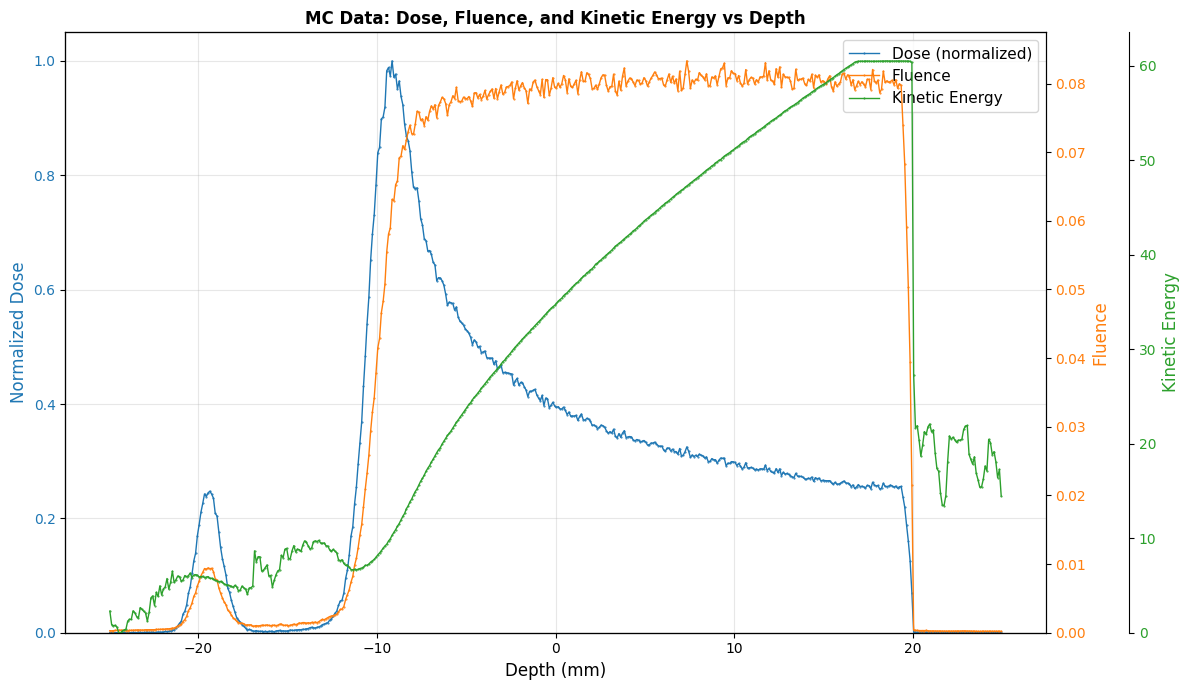

In [67]:
# Plot the merged data
plot_mc_data(df_merged, 'MC Data: Dose, Fluence, and Kinetic Energy vs Depth')

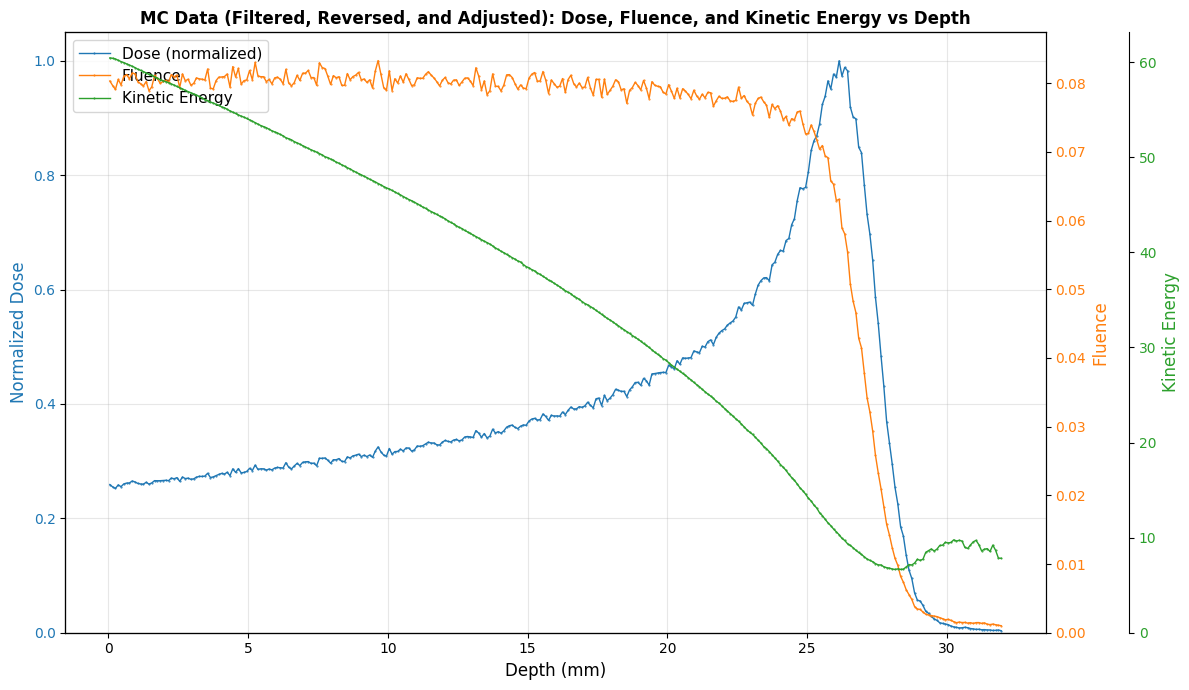

In [68]:
# Plot the filtered, reversed, and adjusted data
plot_mc_data(df_mc, 'MC Data (Filtered, Reversed, and Adjusted): Dose, Fluence, and Kinetic Energy vs Depth')

In [69]:
# Calculate dose metrics for df_mc
if 'df_mc' in locals() and not df_mc.empty:
    metrics = calculate_dose_metrics(df_mc, "MC Data (Filtered & Adjusted)")
else:
    print("MC data not loaded")
    metrics = None

=== MC Data (Filtered & Adjusted) Metrics ===
Range (distance at dose 0.9): 2.6708 cm
Distance at dose 0.1: 2.8715 cm
Drop from 0.9 to 0.1: 0.2007 cm
FWHM: 0.6379 cm
Left edge of FWHM (0.5): 2.1242 cm
Right edge of FWHM (0.5): 2.7621 cm
Inverse of first point value: 3.8600



In [70]:
df_mc.to_hdf('ccb.h5', key='mc_wedge', mode='a')